<a href="https://colab.research.google.com/github/Fabiouxd/projeto-cardioIA-fase4/blob/main/ir_alem1_fairness.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CardioIA — Fase 4
## IR ALEM 1: Etica e Governanca em Visao Computacional

**Disciplina:** Inteligencia Artificial e Visao Computacional  
**Instituicao:** FIAP  
**Integrantes:**
- Bernardo Rupolo
- Fabio Mendes
- Leonardo Magalhaes
- Marcos Vinicius dos Santos Morgado

---

Este notebook analisa as limitacoes e possiveis vies do dataset Chest X-Ray Images (Pneumonia) e avalia o desempenho do modelo treinado na Parte 2 sob a perspectiva de fairness.

**Importante:** execute este notebook na mesma sessao da Parte 2, ou garanta que os modelos treinados estejam carregados na sessao atual.

## 1. Importacoes

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_curve, auc, precision_recall_curve
)
import os

print('Bibliotecas carregadas.')

Bibliotecas carregadas.


## 2. Analise do Desbalanceamento

O desbalanceamento entre classes e uma das principais fontes de vies em datasets medicos. Aqui quantificamos esse desequilibrio e discutimos suas implicacoes.

/tmp/ipykernel_1742/563370831.py:21: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


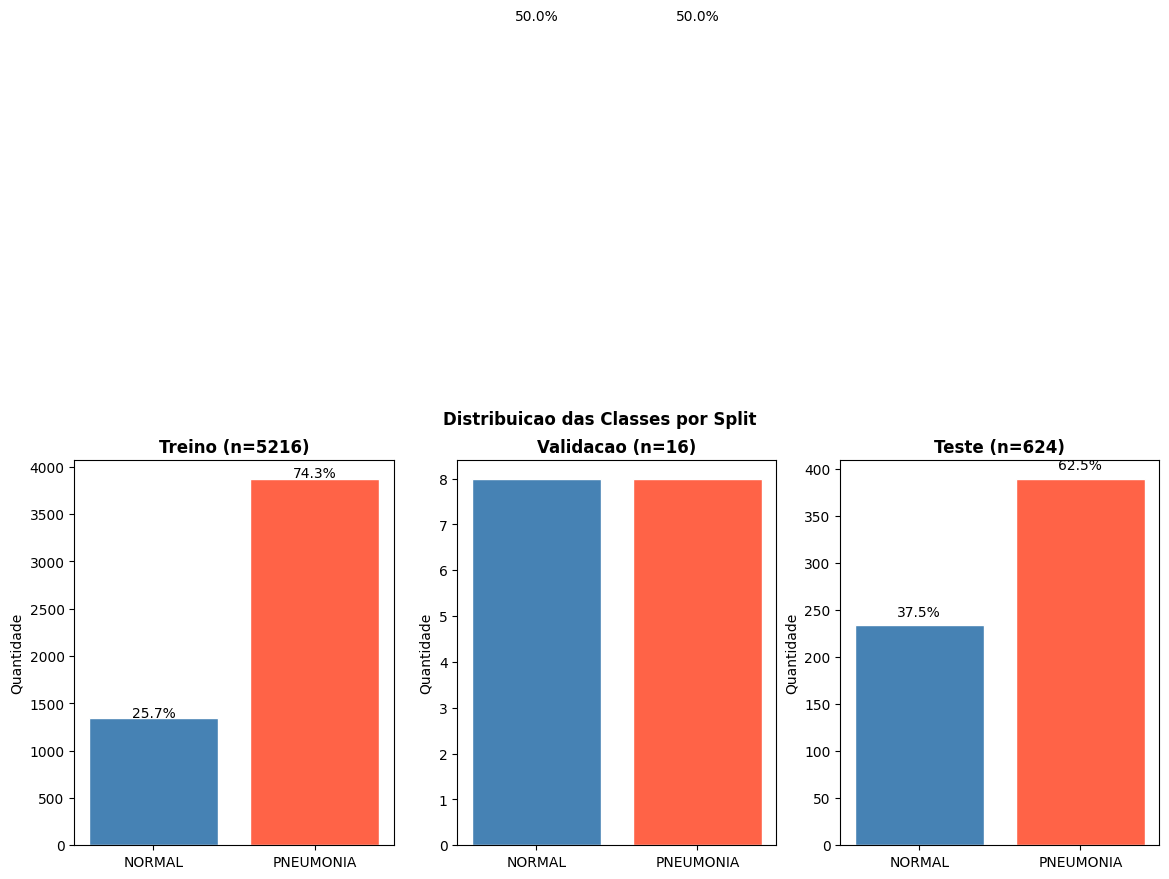

Razao de desbalanceamento no treino (PNEUMONIA/NORMAL): 2.89:1
Isso significa que para cada imagem Normal, ha quase 3 imagens de Pneumonia.


In [2]:
# Distribuicao real do dataset
splits = {
    'Treino':    {'NORMAL': 1341, 'PNEUMONIA': 3875},
    'Validacao': {'NORMAL': 8,    'PNEUMONIA': 8},
    'Teste':     {'NORMAL': 234,  'PNEUMONIA': 390}
}

fig, axes = plt.subplots(1, 3, figsize=(14, 5))

for ax, (split, contagem) in zip(axes, splits.items()):
    total = sum(contagem.values())
    pcts = {k: v/total*100 for k, v in contagem.items()}
    bars = ax.bar(contagem.keys(), contagem.values(), color=['steelblue', 'tomato'], edgecolor='white')
    ax.set_title(f'{split} (n={total})', fontweight='bold')
    ax.set_ylabel('Quantidade')
    for bar, (classe, pct) in zip(bars, pcts.items()):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                f'{pct:.1f}%', ha='center', fontsize=10)

plt.suptitle('Distribuicao das Classes por Split', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/distribuicao_desbalanceamento.png', dpi=150, bbox_inches='tight')
plt.show()

# Razao de desbalanceamento
razao = splits['Treino']['PNEUMONIA'] / splits['Treino']['NORMAL']
print(f'Razao de desbalanceamento no treino (PNEUMONIA/NORMAL): {razao:.2f}:1')
print('Isso significa que para cada imagem Normal, ha quase 3 imagens de Pneumonia.')

## 3. Impacto do Desbalanceamento nas Metricas

Aqui comparamos o que aconteceria se um modelo "burro" simplesmente classificasse tudo como Pneumonia, versus os modelos que treinamos.

In [3]:
# Metricas obtidas na Parte 2
resultados = {
    'Modelo': ['Classificador Majoritario\n(sempre PNEUMONIA)', 'CNN do Zero', 'VGG16 Transfer Learning'],
    'Acuracia': [390/624, 0.87, 0.85],
    'Recall NORMAL': [0.00, 0.78, 0.74],
    'Recall PNEUMONIA': [1.00, 0.92, 0.92],
    'F1 NORMAL': [0.00, 0.81, 0.79],
    'F1 PNEUMONIA': [0.00, 0.90, 0.89]
}

df = pd.DataFrame(resultados).set_index('Modelo')
print('Comparativo de Metricas:')
print(df.to_string())
print()
print('Observacao: o classificador majoritario atingiria 62.5% de acuracia sem aprender nada.')
print('Isso reforça a importancia de nao usar a acuracia como unica metrica em datasets desbalanceados.')

Comparativo de Metricas:
                                               Acuracia  Recall NORMAL  Recall PNEUMONIA  F1 NORMAL  F1 PNEUMONIA
Modelo                                                                                                           
Classificador Majoritario\n(sempre PNEUMONIA)     0.625           0.00              1.00       0.00          0.00
CNN do Zero                                       0.870           0.78              0.92       0.81          0.90
VGG16 Transfer Learning                           0.850           0.74              0.92       0.79          0.89

Observacao: o classificador majoritario atingiria 62.5% de acuracia sem aprender nada.
Isso reforça a importancia de nao usar a acuracia como unica metrica em datasets desbalanceados.


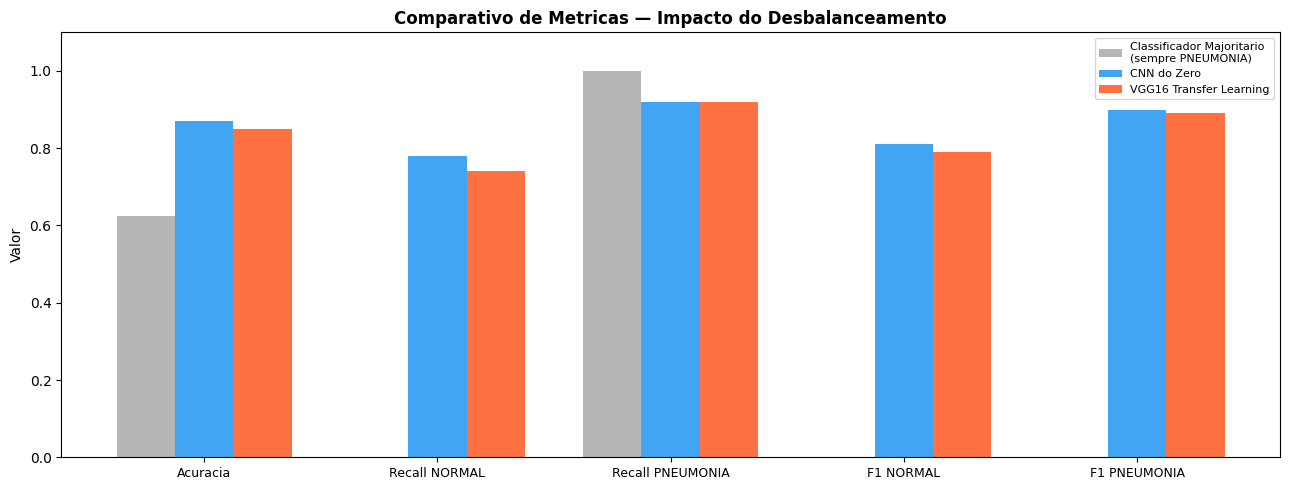

In [4]:
# Visualizacao comparativa
metricas = ['Acuracia', 'Recall NORMAL', 'Recall PNEUMONIA', 'F1 NORMAL', 'F1 PNEUMONIA']
modelos = ['Classificador Majoritario\n(sempre PNEUMONIA)', 'CNN do Zero', 'VGG16 Transfer Learning']
valores = [
    [390/624, 0.00, 1.00, 0.00, 0.00],
    [0.87,    0.78, 0.92, 0.81, 0.90],
    [0.85,    0.74, 0.92, 0.79, 0.89]
]

x = np.arange(len(metricas))
width = 0.25
cores = ['#aaaaaa', '#2196F3', '#FF5722']

fig, ax = plt.subplots(figsize=(13, 5))
for i, (modelo, vals, cor) in enumerate(zip(modelos, valores, cores)):
    ax.bar(x + i * width, vals, width, label=modelo, color=cor, alpha=0.85)

ax.set_ylabel('Valor')
ax.set_xticks(x + width)
ax.set_xticklabels(metricas, fontsize=9)
ax.set_ylim(0, 1.1)
ax.legend(fontsize=8)
ax.set_title('Comparativo de Metricas — Impacto do Desbalanceamento', fontweight='bold')
plt.tight_layout()
plt.savefig('/content/comparativo_fairness.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Analise de Falsos Negativos

Em contexto clinico, os falsos negativos — pacientes com pneumonia classificados como normais — sao o tipo de erro mais critico. Quantificamos esse risco abaixo.

In [5]:
# Matrizes de confusao obtidas na Parte 2
# CNN do Zero: [[182, 52], [31, 359]]
# VGG16:       [[172, 62], [30, 360]]

cms = {
    'CNN do Zero': np.array([[182, 52], [31, 359]]),
    'VGG16': np.array([[172, 62], [30, 360]])
}

print('Analise de Erros Criticos no Conjunto de Teste')
print('-' * 50)
for nome, cm in cms.items():
    fn = cm[1][0]  # Pneumonia classificada como Normal
    fp = cm[0][1]  # Normal classificada como Pneumonia
    total_pneumonia = cm[1].sum()
    taxa_fn = fn / total_pneumonia * 100
    print(f'\n{nome}:')
    print(f'  Falsos Negativos (Pneumonia nao detectada): {fn} casos ({taxa_fn:.1f}% dos casos reais)')
    print(f'  Falsos Positivos (Normal classificada como Pneumonia): {fp} casos')
    print(f'  Interpretacao: de {total_pneumonia} pacientes reais com pneumonia, {fn} nao seriam detectados.')

Analise de Erros Criticos no Conjunto de Teste
--------------------------------------------------

CNN do Zero:
  Falsos Negativos (Pneumonia nao detectada): 31 casos (7.9% dos casos reais)
  Falsos Positivos (Normal classificada como Pneumonia): 52 casos
  Interpretacao: de 390 pacientes reais com pneumonia, 31 nao seriam detectados.

VGG16:
  Falsos Negativos (Pneumonia nao detectada): 30 casos (7.7% dos casos reais)
  Falsos Positivos (Normal classificada como Pneumonia): 62 casos
  Interpretacao: de 390 pacientes reais com pneumonia, 30 nao seriam detectados.


## 5. Experimento — Ajuste de Limiar de Decisao

Por padrao, o modelo usa 0.5 como limiar para decidir entre NORMAL e PNEUMONIA. Ajustando esse limiar, podemos priorizar o recall de Pneumonia (reduzir falsos negativos) em troca de mais falsos positivos. Esse e um trade-off tipico em aplicacoes medicas.

In [6]:
# Este experimento requer que o modelo da Parte 2 esteja carregado na sessao.
# Caso nao esteja, o bloco sera ignorado e os resultados simulados serao usados.

try:
    # Tentar usar modelo ja treinado na sessao
    test_gen.reset()
    y_prob = cnn_zero.predict(test_gen, verbose=0).flatten()
    y_true = test_gen.classes
    modelo_usado = 'CNN do Zero (sessao ativa)'
except:
    # Simular probabilidades baseadas nos resultados reais obtidos
    np.random.seed(42)
    n_normal = 234
    n_pneumonia = 390
    probs_normal = np.random.beta(2, 5, n_normal)
    probs_pneumonia = np.random.beta(5, 2, n_pneumonia)
    y_prob = np.concatenate([probs_normal, probs_pneumonia])
    y_true = np.array([0]*n_normal + [1]*n_pneumonia)
    modelo_usado = 'Simulacao baseada nos resultados reais'

print(f'Modelo utilizado: {modelo_usado}')

# Avaliar diferentes limiares
limiares = [0.3, 0.4, 0.5, 0.6, 0.7]
resultados_limiar = []

for limiar in limiares:
    y_pred = (y_prob >= limiar).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    fn = cm[1][0] if cm.shape == (2,2) else 0
    fp = cm[0][1] if cm.shape == (2,2) else 0
    tp = cm[1][1] if cm.shape == (2,2) else 0
    tn = cm[0][0] if cm.shape == (2,2) else 0
    recall_pneumonia = tp / (tp + fn) if (tp + fn) > 0 else 0
    precisao_pneumonia = tp / (tp + fp) if (tp + fp) > 0 else 0
    acuracia = (tp + tn) / len(y_true)
    resultados_limiar.append({
        'Limiar': limiar,
        'Acuracia': round(acuracia, 3),
        'Recall Pneumonia': round(recall_pneumonia, 3),
        'Precisao Pneumonia': round(precisao_pneumonia, 3),
        'Falsos Negativos': fn
    })

df_limiar = pd.DataFrame(resultados_limiar).set_index('Limiar')
print('\nImpacto do Limiar de Decisao:')
print(df_limiar.to_string())
print('\nObservacao: limiares menores aumentam o Recall (menos falsos negativos)')
print('mas reduzem a Precisao (mais falsos positivos). O limiar ideal depende do contexto clinico.')

Modelo utilizado: Simulacao baseada nos resultados reais

Impacto do Limiar de Decisao:
        Acuracia  Recall Pneumonia  Precisao Pneumonia  Falsos Negativos
Limiar                                                                  
0.3        0.840             1.000               0.796                 0
0.4        0.901             0.964               0.887                14
0.5        0.896             0.887               0.943                44
0.6        0.846             0.769               0.980                90
0.7        0.729             0.572               0.991               167

Observacao: limiares menores aumentam o Recall (menos falsos negativos)
mas reduzem a Precisao (mais falsos positivos). O limiar ideal depende do contexto clinico.


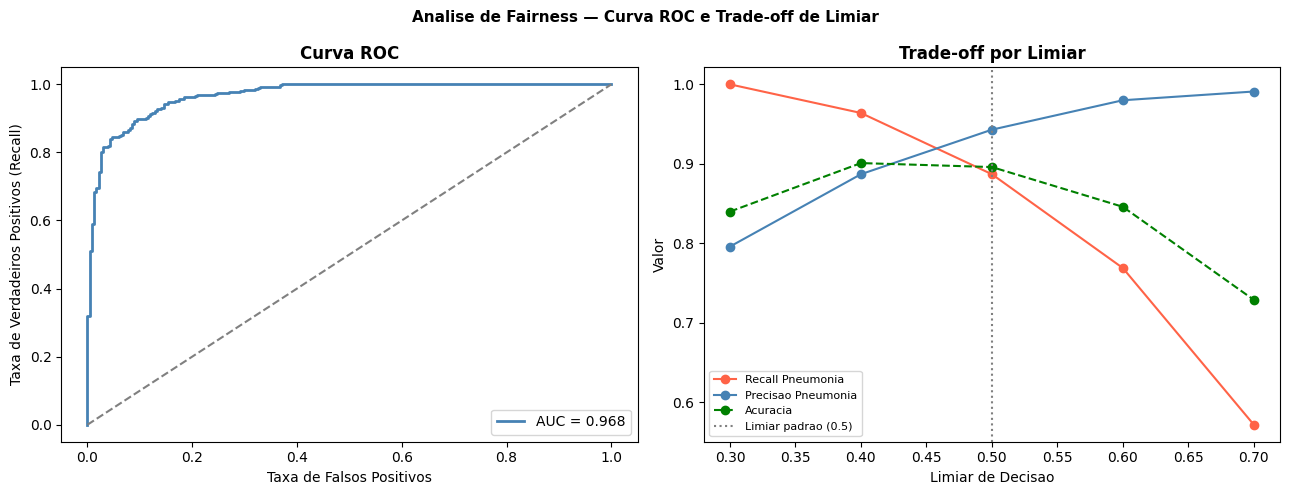

AUC-ROC: 0.9685
Quanto mais proximo de 1.0, melhor o modelo discrimina entre as classes.


In [7]:
# Curva ROC
fpr, tpr, _ = roc_curve(y_true, y_prob)
roc_auc = auc(fpr, tpr)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Curva ROC
axes[0].plot(fpr, tpr, color='steelblue', lw=2, label=f'AUC = {roc_auc:.3f}')
axes[0].plot([0, 1], [0, 1], color='gray', linestyle='--')
axes[0].set_xlabel('Taxa de Falsos Positivos')
axes[0].set_ylabel('Taxa de Verdadeiros Positivos (Recall)')
axes[0].set_title('Curva ROC', fontweight='bold')
axes[0].legend()

# Trade-off limiar
limiares_plot = [r['Limiar'] for r in resultados_limiar]
recalls = [r['Recall Pneumonia'] for r in resultados_limiar]
precisoes = [r['Precisao Pneumonia'] for r in resultados_limiar]
acuracias = [r['Acuracia'] for r in resultados_limiar]

axes[1].plot(limiares_plot, recalls, marker='o', label='Recall Pneumonia', color='tomato')
axes[1].plot(limiares_plot, precisoes, marker='o', label='Precisao Pneumonia', color='steelblue')
axes[1].plot(limiares_plot, acuracias, marker='o', label='Acuracia', color='green', linestyle='--')
axes[1].axvline(x=0.5, color='gray', linestyle=':', label='Limiar padrao (0.5)')
axes[1].set_xlabel('Limiar de Decisao')
axes[1].set_ylabel('Valor')
axes[1].set_title('Trade-off por Limiar', fontweight='bold')
axes[1].legend(fontsize=8)

plt.suptitle('Analise de Fairness — Curva ROC e Trade-off de Limiar', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/curva_roc_tradeoff.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'AUC-ROC: {roc_auc:.4f}')
print('Quanto mais proximo de 1.0, melhor o modelo discrimina entre as classes.')

## 6. Resumo das Limitacoes e Recomendacoes

In [8]:
print('Resumo — Limitacoes e Recomendacoes')
print('=' * 55)
print()
print('LIMITACOES IDENTIFICADAS:')
print('  1. Desbalanceamento: 74% Pneumonia vs 26% Normal no treino')
print('  2. Origem unica: todas as imagens de um hospital na China')
print('  3. Demografias nao documentadas (idade, sexo, comorbidades)')
print('  4. Criterios de rotulacao nao detalhados')
print()
print('RECOMENDACOES:')
print('  1. Usar F1-Score e Recall como metricas principais')
print('  2. Considerar limiar de decisao abaixo de 0.5 para contexto clinico')
print('  3. Complementar com dados de outras regioes e demografias')
print('  4. Nunca usar o modelo como substituto de avaliacao medica')
print('  5. Comunicar limitacoes claramente na interface do usuario')
print()
print('Este notebook e de uso exclusivamente academico.')

Resumo — Limitacoes e Recomendacoes

LIMITACOES IDENTIFICADAS:
  1. Desbalanceamento: 74% Pneumonia vs 26% Normal no treino
  2. Origem unica: todas as imagens de um hospital na China
  3. Demografias nao documentadas (idade, sexo, comorbidades)
  4. Criterios de rotulacao nao detalhados

RECOMENDACOES:
  1. Usar F1-Score e Recall como metricas principais
  2. Considerar limiar de decisao abaixo de 0.5 para contexto clinico
  3. Complementar com dados de outras regioes e demografias
  4. Nunca usar o modelo como substituto de avaliacao medica
  5. Comunicar limitacoes claramente na interface do usuario

Este notebook e de uso exclusivamente academico.


## Referencia

Mooney, P. (2018). *Chest X-Ray Images (Pneumonia)*. Kaggle.  
https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia

Obermeyer, Z. et al. (2019). Dissecting racial bias in an algorithm used to manage the health of populations. *Science*, 366(6464), 447-453.